# 1 — The dataset, and the decision hiding behind it

30,000 Taiwanese credit-card accounts observed April–September 2005, with a
binary outcome for October. The dataset is famous as a classification
benchmark; this notebook is mostly about the things that stop it being one.

Three questions:

1. What is actually in the data, and what is undocumented?
2. How different are the two ways of being wrong?
3. Who is in each group, and do the groups differ before the model touches them?

In [1]:
import sys, json
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import get_splits, load_clean, load_raw
from src.data.schema import (
    BILL_COLS, EDUCATION_LABELS, MARRIAGE_LABELS, PAYAMT_COLS,
    REPAY_COLS, SEX_LABELS,
)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dcdbd6"
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
})

raw = load_raw()
df = load_clean()
print(f"{len(df):,} accounts x {df.shape[1]} columns")
print(f"default rate: {df['default'].mean():.4f}")

30,000 accounts x 26 columns
default rate: 0.2212


## The codebook is incomplete in three places

Every one of these is a decision someone has to make before modelling, and
every one of them is usually made silently.

In [2]:
for col, documented in [("EDUCATION", {1, 2, 3, 4}), ("MARRIAGE", {1, 2, 3})]:
    counts = raw[col].value_counts().sort_index()
    undoc = {int(k): int(v) for k, v in counts.items() if k not in documented}
    print(f"{col:10s} codes in data: {sorted(int(k) for k in counts.index)}")
    print(f"{'':10s} undocumented : {undoc}  ({sum(undoc.values())} rows)")

print()
print("PAY_0 (September repayment status), all codes:")
print(raw["PAY_0"].value_counts().sort_index().to_string())
print()
print("The codebook documents -1 and 1..9. It does not document -2 or 0,")
print("which together are", f"{(raw['PAY_0'] <= 0).mean():.1%}", "of the column.")

EDUCATION  codes in data: [0, 1, 2, 3, 4, 5, 6]
           undocumented : {0: 14, 5: 280, 6: 51}  (345 rows)
MARRIAGE   codes in data: [0, 1, 2, 3]
           undocumented : {0: 54}  (54 rows)

PAY_0 (September repayment status), all codes:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19

The codebook documents -1 and 1..9. It does not document -2 or 0,
which together are 77.3% of the column.


`-2` and `0` are read here as *no balance to repay* and *revolving credit,
minimum paid*. The billing columns support that reading: accounts coded `-2`
carry almost no bill, while `0` accounts carry by far the largest ones.

Note what that does to the ordering. Customers who revolve a large balance
(`0`, median bill NT$49,605) default **less** than customers who paid in
full on a small one (`-1`, median bill NT$2,740) — 0.128 against 0.168. The
column is not an ordinal risk scale below 1, and a model that treats it as
one is asserting something the data does not say.

In [3]:
for code in (-2, -1, 0, 1, 2):
    m = raw["PAY_0"] == code
    print(f"PAY_0 = {code:>2}  n={int(m.sum()):>6,}  "
          f"median BILL_AMT1 = {raw.loc[m, 'BILL_AMT1'].median():>9,.0f}  "
          f"default rate = {raw.loc[m, raw.columns[-1]].mean():.4f}")

PAY_0 = -2  n= 2,759  median BILL_AMT1 =     1,179  default rate = 0.1323
PAY_0 = -1  n= 5,686  median BILL_AMT1 =     2,740  default rate = 0.1678
PAY_0 =  0  n=14,737  median BILL_AMT1 =    49,605  default rate = 0.1281
PAY_0 =  1  n= 3,688  median BILL_AMT1 =     4,606  default rate = 0.3395
PAY_0 =  2  n= 2,667  median BILL_AMT1 =    41,632  default rate = 0.6914


The last column is the one that matters: default rate climbs from 0.13 at
"no balance" to well above 0.5 once an account is two months late. **One
integer column carries most of the signal in this dataset** — which is why
the baseline ladder starts with a lookup table on it.

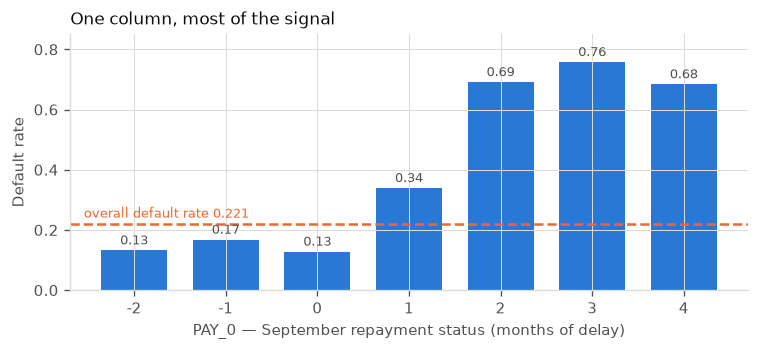

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
g = raw.groupby("PAY_0")[raw.columns[-1]].agg(["mean", "size"])
g = g[g["size"] >= 50]
ax.bar(g.index.astype(str), g["mean"], color=BLUE, width=0.72)
for x, (rate, n) in enumerate(zip(g["mean"], g["size"])):
    ax.text(x, rate + 0.02, f"{rate:.2f}", ha="center", fontsize=8, color=MUTED)
ax.axhline(df["default"].mean(), color=ORANGE, lw=1.5, ls="--")
ax.text(0.02, df["default"].mean() + 0.02, "overall default rate 0.221",
        transform=ax.get_yaxis_transform(), fontsize=8, color=ORANGE)
ax.set_xlabel("PAY_0 — September repayment status (months of delay)")
ax.set_ylabel("Default rate")
ax.set_ylim(0, 0.85)
ax.set_title("One column, most of the signal", loc="left", color=INK, fontsize=10)
plt.tight_layout(); plt.show()

## The two errors are not the same size

The dataset is 22% positive. Almost every published treatment of it reports
accuracy, or AUC, and stops. Both of those assume the two mistakes are worth
comparing on equal terms.

They are not. Declining a customer who would have paid costs the margin on
their balance. Approving one who defaults costs the balance. Here is the
distribution of what is actually at stake per account.

balance at risk   median NT$22,382   mean NT$51,246   max NT$964,511
top 1% of accounts hold 8.4% of all exposure
bottom 50% hold 6.2%


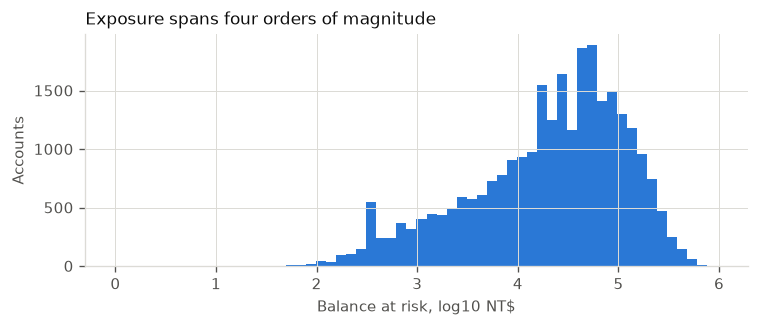

In [5]:
exposure = np.maximum(df["BILL_AMT1"], 0)
print(f"balance at risk   median NT${exposure.median():,.0f}   "
      f"mean NT${exposure.mean():,.0f}   max NT${exposure.max():,.0f}")
print(f"top 1% of accounts hold "
      f"{exposure.nlargest(len(df)//100).sum() / exposure.sum():.1%} of all exposure")
print(f"bottom 50% hold "
      f"{exposure.nsmallest(len(df)//2).sum() / exposure.sum():.1%}")

fig, ax = plt.subplots(figsize=(6.4, 2.8))
ax.hist(np.log10(exposure[exposure > 0]), bins=60, color=BLUE)
ax.set_xlabel("Balance at risk, log10 NT$")
ax.set_ylabel("Accounts")
ax.set_title("Exposure spans four orders of magnitude", loc="left",
             color=INK, fontsize=10)
plt.tight_layout(); plt.show()

**This is why "how many defaults did you catch" is the wrong question.**
The 300 largest accounts hold 8.4% of all the money at risk; the 15,000
smallest hold 6.2%. Fifty times fewer accounts, more money. A policy that
catches many small defaults and misses a few large ones scores well on
recall and loses more than one that does the reverse.

## Who is in the data

The groups differ in default rate before any model exists. That matters
later: a single threshold applied to a well-ranked model will produce
different error rates across groups *because of this*, not because the model
learned something objectionable.

In [6]:
for col, labels in [("SEX", SEX_LABELS), ("EDUCATION", EDUCATION_LABELS),
                    ("MARRIAGE", MARRIAGE_LABELS)]:
    g = df.groupby(col)["default"].agg(["size", "mean"])
    print(col)
    for key, row in g.iterrows():
        print(f"   {labels.get(int(key), key):16s} n={int(row['size']):>6,}  "
              f"default rate {row['mean']:.4f}")
    print()

g = df.groupby("AGE_BAND")["default"].agg(["size", "mean"])
print("AGE_BAND")
for key, row in g.iterrows():
    print(f"   {key:16s} n={int(row['size']):>6,}  default rate {row['mean']:.4f}")

SEX
   Male             n=11,888  default rate 0.2417
   Female           n=18,112  default rate 0.2078

EDUCATION
   Graduate school  n=10,585  default rate 0.1923
   University       n=14,030  default rate 0.2373
   High school      n= 4,917  default rate 0.2516
   Other/unknown    n=   468  default rate 0.0705

MARRIAGE
   Married          n=13,659  default rate 0.2347
   Single           n=15,964  default rate 0.2093
   Other/unknown    n=   377  default rate 0.2361

AGE_BAND
   21-29            n= 9,618  default rate 0.2284
   30-39            n=11,238  default rate 0.2025
   40-49            n= 6,464  default rate 0.2297
   50+              n= 2,680  default rate 0.2530


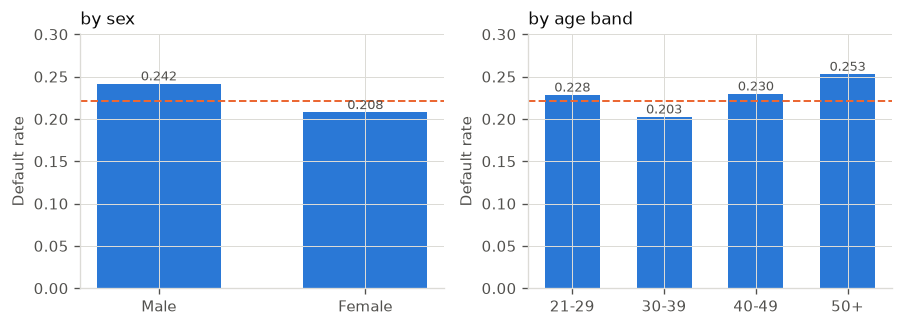

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 2.8))
for ax, (col, labels, title) in zip(axes, [
        ("SEX", SEX_LABELS, "by sex"), ("AGE_BAND", None, "by age band")]):
    g = df.groupby(col)["default"].mean()
    names = [labels[int(k)] for k in g.index] if labels else list(g.index)
    ax.bar(names, g.values, color=BLUE, width=0.6)
    for x, v in enumerate(g.values):
        ax.text(x, v + 0.004, f"{v:.3f}", ha="center", fontsize=8, color=MUTED)
    ax.axhline(df["default"].mean(), color=ORANGE, lw=1.2, ls="--")
    ax.set_ylim(0, 0.30); ax.set_ylabel("Default rate")
    ax.set_title(title, loc="left", color=INK, fontsize=10)
plt.tight_layout(); plt.show()

## The split

25% held out for a single test pass; 20% of the rest for validation.
Stratified on the outcome, because every threshold in this project is
computed against the base rate and an unstratified split would move it.

In [8]:
train, val, test = get_splits()
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:6s} {len(part):>6,}  default rate {part['default'].mean():.4f}")
print()
print("test split, smallest reportable cells:")
for attr in ("SEX", "AGE_BAND", "EDUCATION"):
    g = test.groupby(attr)["default"].agg(["size", "sum"])
    smallest = g["size"].idxmin()
    print(f"   {attr:10s} smallest group {smallest}: "
          f"n={int(g.loc[smallest, 'size']):,}, "
          f"{int(g.loc[smallest, 'sum'])} defaults")

train  18,000  default rate 0.2212
val     4,500  default rate 0.2211
test    7,500  default rate 0.2212

test split, smallest reportable cells:


   SEX        smallest group 1: n=3,017, 743 defaults
   AGE_BAND   smallest group 50+: n=663, 169 defaults
   EDUCATION  smallest group 4: n=119, 4 defaults


The education "other/unknown" cell is 119 accounts with 4 defaults. It is
carried through the pipeline but excluded from every disparity number, and
the audit says so rather than quietly averaging it in.

Next: `02_results.ipynb` — the model ladder, and why AUC is the wrong place
to stop.